# NSCLC Brain-Met MIL Benchmark

**Project:** Pretraining Strategy Matters: Benchmarking WSI Encoders for Brain Metastasis Risk Prediction in NSCLC  
**Pipeline:** Frozen encoder → cached tile features → Attention MIL → slide-level prediction  
**Dataset:** Zhou et al. (2024) NSCLC dataset — 158 slides, 1000 tiles/slide, BM+ vs BM−

### Arms
| Arm | Encoder | Pretraining |
|-----|---------|-------------|
| A | ViT-Tiny (yours) | DINO on TCIA (task-specific SSL) |
| B | UNI | DINOv2 on 100k+ pathology slides |
| C | CONCH | Vision-language on PathChat |
| D | ViT-Small | Supervised ImageNet (baseline) |

### Run order
**Cell 0 → restart → Cell 1 → 2 → 3 → 4 → 5 → 6 → 7 → 8**  
Set `ARM` in Cell 1 before running.

In [5]:
# ── CELL 0 — Install dependencies (run once, then restart runtime) ──────────
import subprocess

pkgs = [
    ('pip', ['pip', 'install', '-q', '--upgrade', 'pip']),
    ('timm==0.9.16', ['pip', 'install', '-q', 'timm==0.9.16']),
    ('einops', ['pip', 'install', '-q', 'einops']),
    ('transformers', ['pip', 'install', '-q', 'transformers']),
    ('huggingface_hub', ['pip', 'install', '-q', 'huggingface_hub']),
    # CONCH (needed for Arm C only — comment out if not running Arm C)
    # ('CONCH', ['pip', 'install', '-q', 'git+https://github.com/mahmoodlab/CONCH.git']),
]

for name, cmd in pkgs:
    print(f'Installing {name}...', end=' ', flush=True)
    r = subprocess.run(cmd, capture_output=True)
    print('OK' if r.returncode == 0 else f'FAILED\n{r.stderr.decode()}')

print('\nDone. Restart runtime, then run from Cell 1.')


Installing pip... OK
Installing timm==0.9.16... OK
Installing einops... OK
Installing transformers... OK
Installing huggingface_hub... OK

Done. Restart runtime, then run from Cell 1.


In [6]:
# ── CELL 1 — Imports and Config ─────────────────────────────────────────────
import os, sys, time, random, glob, json, gc
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import timm

from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score

import warnings
warnings.filterwarnings('ignore')

# ── SEED ────────────────────────────────────────────────────────────────────
SEED = 1
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    p = torch.cuda.get_device_properties(0)
    print(f'GPU: {p.name} | VRAM: {p.total_memory/1e9:.1f} GB')

# ╔══════════════════════════════════════════════════════════════════════════╗
# ║                  SELECT ARM HERE                                        ║
# ║  'A' = ViT-Tiny DINO (yours)   'B' = UNI      'C' = CONCH             ║
# ║  'D' = ImageNet ViT             'E' = Virchow2  'F' = Prov-GigaPath    ║
# ║  'G' = H-optimus-0              'H' = Phikon-v2 'I' = UNI2-h           ║
# ║  'J' = Hibou-L                                                         ║
# ╚══════════════════════════════════════════════════════════════════════════╝
ARM = 'G'                                        # ← change this per arm

# ── PATHS ───────────────────────────────────────────────────────────────────
DATA_DIR    = Path('/kaggle/input/datasets/mdashiqsj/zhou-wsi/zhou_dt')
INDEX_DIR   = DATA_DIR / 'Index'
TRAIN_DIR   = DATA_DIR / 'train'
TEST_DIR    = DATA_DIR / 'test'
OUTPUT_DIR  = Path('/kaggle/working/mil_benchmark')
FEAT_DIR    = OUTPUT_DIR / f'features_arm_{ARM}'
CKPT_DIR    = OUTPUT_DIR / f'checkpoints_arm_{ARM}'
RESULTS_DIR = OUTPUT_DIR / 'results'

ARM_A_CKPT = Path('/kaggle/input/your-dino-encoder/tcia_dino_encoder.pt')

for d in [OUTPUT_DIR, FEAT_DIR, CKPT_DIR, RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── ARM CONFIGS ──────────────────────────────────────────────────────────────
ARM_CONFIGS = {
    'A': {
        'name'      : 'ViT-Tiny DINO (TCIA)',
        'timm_model': 'vit_tiny_patch16_224.augreg_in21k',
        'embed_dim' : 192,
        'source'    : 'local',
        'ckpt'      : ARM_A_CKPT,
        'img_size'  : 224,
        'mean'      : [0.485, 0.456, 0.406],
        'std'       : [0.229, 0.224, 0.225],
    },
    'B': {
        'name'      : 'UNI',
        'timm_model': 'vit_large_patch16_224',
        'embed_dim' : 1024,
        'source'    : 'huggingface',
        'hf_repo'   : 'MahmoodLab/UNI',
        'img_size'  : 224,
        'mean'      : [0.485, 0.456, 0.406],
        'std'       : [0.229, 0.224, 0.225],
    },
    'C': {
        'name'      : 'CONCH',
        'embed_dim' : 512,
        'source'    : 'huggingface',
        'hf_repo'   : 'MahmoodLab/CONCH',
        'img_size'  : 224,
        'mean'      : [0.485, 0.456, 0.406],
        'std'       : [0.229, 0.224, 0.225],
    },
    'D': {
        'name'      : 'ViT-Small ImageNet (Baseline)',
        'timm_model': 'vit_small_patch16_224.augreg_in21k',
        'embed_dim' : 384,
        'source'    : 'timm',
        'img_size'  : 224,
        'mean'      : [0.485, 0.456, 0.406],
        'std'       : [0.229, 0.224, 0.225],
    },
    # ── New arms ──────────────────────────────────────────────────────────
    'E': {
        'name'      : 'Virchow2',
        'embed_dim' : 1280,
        'source'    : 'huggingface',
        'hf_repo'   : 'paige-ai/Virchow2',
        'img_size'  : 224,
        'mean'      : [0.485, 0.456, 0.406],
        'std'       : [0.229, 0.224, 0.225],
    },
    'F': {
        'name'      : 'Prov-GigaPath',
        'embed_dim' : 1536,
        'source'    : 'huggingface',
        'hf_repo'   : 'prov-gigapath/prov-gigapath',
        'img_size'  : 256,           # GigaPath uses 256x256 tiles
        'mean'      : [0.485, 0.456, 0.406],
        'std'       : [0.229, 0.224, 0.225],
    },
    'G': {
        'name'      : 'H-optimus-0',
        'embed_dim' : 1536,
        'source'    : 'huggingface',
        'hf_repo'   : 'bioptimus/H-optimus-0',
        'img_size'  : 224,
        'mean'      : [0.707223, 0.578729, 0.703617],
        'std'       : [0.211883, 0.230117, 0.177517],
    },
    'H': {
        'name'      : 'Phikon-v2',
        'embed_dim' : 1024,
        'source'    : 'huggingface',
        'hf_repo'   : 'owkin/phikon-v2',
        'img_size'  : 224,
        'mean'      : [0.485, 0.456, 0.406],
        'std'       : [0.229, 0.224, 0.225],
    },
    'I': {
        'name'      : 'UNI2-h',
        'embed_dim' : 1536,
        'source'    : 'huggingface',
        'hf_repo'   : 'MahmoodLab/UNI2-h',
        'img_size'  : 224,
        'mean'      : [0.485, 0.456, 0.406],
        'std'       : [0.229, 0.224, 0.225],
    },
    'J': {
        'name'      : 'Hibou-L',
        'embed_dim' : 1024,
        'source'    : 'huggingface',
        'hf_repo'   : 'histai/hibou-l',
        'img_size'  : 224,
        'mean'      : [0.7068, 0.5655, 0.7220],
        'std'       : [0.1951, 0.2316, 0.1816],
    },
}

# ── MIL TRAINING CONFIG ──────────────────────────────────────────────────────
MIL_CFG = {
    'n_splits'       : 3,
    'num_test'       : 40,
    'n_cv_folds'     : 3,
    'num_val'        : 30,
    'tile_per_slide' : 1000,
    'mil_hidden'     : 256,
    'mil_dropout'    : 0.25,
    'lr'             : 1e-3,
    'weight_decay'   : 0.1,
    'n_epochs'       : 50,
    'patience'       : 15,
}

CFG = ARM_CONFIGS[ARM]
print(f'\nArm {ARM}: {CFG["name"]}')
print(f'Embed dim: {CFG["embed_dim"]}')
print(f'MIL config: {MIL_CFG}')


Device: cuda
GPU: Tesla T4 | VRAM: 15.6 GB

Arm G: H-optimus-0
Embed dim: 1536
MIL config: {'n_splits': 3, 'num_test': 40, 'n_cv_folds': 3, 'num_val': 30, 'tile_per_slide': 1000, 'mil_hidden': 256, 'mil_dropout': 0.25, 'lr': 0.001, 'weight_decay': 0.1, 'n_epochs': 50, 'patience': 15}


In [7]:
# ── CELL 2 — Load Index Files and Build Slide Manifest ──────────────────────
iminfo_train = pd.read_csv(INDEX_DIR / 'iminfo_train.csv')
iminfo_test  = pd.read_csv(INDEX_DIR / 'iminfo_test.csv')
iminfo_list  = pd.concat([iminfo_train, iminfo_test], ignore_index=True)
iminfo_list  = iminfo_list.sort_values(by=['Slide', 'Index']).reset_index(drop=True)
del iminfo_train, iminfo_test

tile_per_slide = MIL_CFG['tile_per_slide']
n_slides = len(iminfo_list) // tile_per_slide
print(f'Total tiles: {len(iminfo_list)} | Slides: {n_slides}')

slides_BM, slides_C = [], []
slide_manifest = []

for idx in range(n_slides):
    row      = iminfo_list.iloc[idx * tile_per_slide]
    slide_id = int(row['Slide'])
    label    = int(row['Class'])  # 0=BM (Met+), 1=C (Met-)
    slide_manifest.append({'slide_id': slide_id, 'label': label})
    if label == 0:
        slides_BM.append(slide_id)
    else:
        slides_C.append(slide_id)

slides_BM = np.array(slides_BM)
slides_C  = np.array(slides_C)
slide_df  = pd.DataFrame(slide_manifest)

print(f'BM (Met+) slides: {len(slides_BM)}')
print(f'C  (Met-) slides: {len(slides_C)}')
print(f'Total slides    : {len(slide_df)}')

def make_splits(slides_BM, slides_C, n_splits, num_test, seed=1):
    """Replicates Zhou's shuffle() — balanced BM/C test splits."""
    rng = np.random.RandomState(seed)
    bm  = slides_BM.copy()
    c   = slides_C.copy()
    rng.shuffle(bm)
    rng.shuffle(c)
    half   = num_test // 2
    splits = []
    for fold in range(n_splits):
        test_slides = np.concatenate([
            bm[fold * half : fold * half + half],
            c [fold * half : fold * half + half],
        ])
        splits.append(test_slides.astype(int))
    return splits

test_splits = make_splits(
    slides_BM, slides_C,
    n_splits=MIL_CFG['n_splits'],
    num_test=MIL_CFG['num_test'],
    seed=SEED,
)
np.save(RESULTS_DIR / 'test_splits.npy', np.array(test_splits))
print(f'\nSplits generated. Test slides per split: {len(test_splits[0])}')
for i, s in enumerate(test_splits):
    bm_n = sum(1 for sid in s if sid in slides_BM)
    c_n  = sum(1 for sid in s if sid in slides_C)
    print(f'  Split {i}: {len(s)} test slides ({bm_n} BM, {c_n} C)')


Total tiles: 158000 | Slides: 158
BM (Met+) slides: 65
C  (Met-) slides: 93
Total slides    : 158

Splits generated. Test slides per split: 40
  Split 0: 40 test slides (20 BM, 20 C)
  Split 1: 40 test slides (20 BM, 20 C)
  Split 2: 40 test slides (20 BM, 20 C)


In [8]:
# ── CELL 3 — Load Encoder ───────────────────────────────────────────────────
import os
from kaggle_secrets import UserSecretsClient
os.environ['HF_TOKEN'] = UserSecretsClient().get_secret('HF_TOKEN')

import huggingface_hub
huggingface_hub.login(token=os.environ['HF_TOKEN'], add_to_git_credential=False)


def _hf_download(repo_id, local_dir, ignore_patterns=None, max_workers=1):
    """Retry wrapper for snapshot_download."""
    ignore_patterns = ignore_patterns or ['*.md', '*.txt']
    local_dir = Path(local_dir)
    local_dir.mkdir(parents=True, exist_ok=True)
    for attempt in range(3):
        try:
            print(f'  Downloading {repo_id} (attempt {attempt+1}/3)...')
            huggingface_hub.snapshot_download(
                repo_id, local_dir=local_dir,
                ignore_patterns=ignore_patterns,
                max_workers=max_workers)
            return local_dir
        except Exception as e:
            print(f'  Attempt {attempt+1} failed: {e}')
            if attempt == 2:
                raise RuntimeError(f'{repo_id} download failed after 3 attempts: {e}')
            time.sleep(5)


def load_encoder(arm, cfg, device):

    # ── Arm A: local ViT-Tiny DINO ──────────────────────────────────────────
    if arm == 'A':
        encoder = timm.create_model(cfg['timm_model'], pretrained=False, num_classes=0)
        ckpt = torch.load(cfg['ckpt'], map_location='cpu')
        encoder.load_state_dict(ckpt['backbone_state_dict'])
        print(f'Arm A: Loaded DINO ViT-Tiny from {cfg["ckpt"]}')

    # ── Arm B: UNI (ViT-L/16, MahmoodLab) ──────────────────────────────────
    elif arm == 'B':
        local_dir = _hf_download('MahmoodLab/UNI', '/kaggle/working/uni_weights')
        encoder = timm.create_model(
            'vit_large_patch16_224', img_size=224, patch_size=16,
            init_values=1e-5, num_classes=0, dynamic_img_size=True)
        encoder.load_state_dict(
            torch.load(local_dir / 'pytorch_model.bin', map_location='cpu'), strict=True)
        print('Arm B: Loaded UNI')

    # ── Arm C: CONCH (ViT-B/16, vision-language) ────────────────────────────
    elif arm == 'C':
        try:
            from conch.open_clip_custom import create_model_from_pretrained
            model, _ = create_model_from_pretrained('conch_ViT-B-16', 'hf_hub:MahmoodLab/conch')
            class CONCHVisualWrapper(torch.nn.Module):
                def __init__(self, visual):
                    super().__init__()
                    self.visual = visual
                def forward(self, x):
                    out = self.visual(x)
                    return out[0] if isinstance(out, tuple) else out
            encoder = CONCHVisualWrapper(model.visual)
            print('Arm C: Loaded CONCH vision encoder')
        except Exception as e:
            raise RuntimeError(
                f'CONCH load failed: {e}\n'
                'Install: pip install git+https://github.com/mahmoodlab/CONCH.git')

    # ── Arm D: ViT-Small ImageNet-21k (timm) ────────────────────────────────
    elif arm == 'D':
        encoder = timm.create_model(cfg['timm_model'], pretrained=True, num_classes=0)
        print(f'Arm D: Loaded {cfg["timm_model"]} from timm (ImageNet pretrained)')

    # ── Arm E: Virchow2 (ViT-H/14, Paige) ──────────────────────────────────
    elif arm == 'E':
        from timm.layers import SwiGLUPacked

        _virchow2 = timm.create_model(
            'hf-hub:paige-ai/Virchow2',
            pretrained=True,
            mlp_layer=SwiGLUPacked,
            act_layer=torch.nn.SiLU,
            num_classes=0,
            dynamic_img_size=True,
        )

        class Virchow2Wrapper(torch.nn.Module):
            def __init__(self, model):
                super().__init__()
                self.model = model
            def forward(self, x):
                out = self.model(x)
                return out[:, 0]

        encoder = Virchow2Wrapper(_virchow2)
        print('Arm E: Loaded Virchow2')

    # ── Arm F: Prov-GigaPath (ViT-G, Microsoft/Providence) ──────────────────
    elif arm == 'F':
        try:
            encoder = timm.create_model(
                'hf_hub:prov-gigapath/prov-gigapath',
                pretrained=True, num_classes=0,
                img_size=256,
                dynamic_img_size=True)
            print('Arm F: Loaded Prov-GigaPath via timm hub')
        except Exception as e:
            print(f'  timm hub load failed ({e}), falling back to manual download...')
            local_dir = _hf_download(
                'prov-gigapath/prov-gigapath', '/kaggle/working/gigapath_weights')
            encoder = timm.create_model(
                'vit_giant_patch14_dinov2', img_size=256, patch_size=14,
                init_values=1e-5, num_classes=0, dynamic_img_size=True)
            state = torch.load(local_dir / 'pytorch_model.bin', map_location='cpu')
            state = {k.replace('model.', ''): v for k, v in state.items()}
            encoder.load_state_dict(state, strict=False)
            print('Arm F: Loaded Prov-GigaPath (manual)')

    # ── Arm G: H-optimus-0 (ViT-G, Bioptimus) ───────────────────────────────
    elif arm == 'G':
        try:
            encoder = timm.create_model(
                'hf-hub:bioptimus/H-optimus-0',
                pretrained=True, num_classes=0, dynamic_img_size=True)
            print('Arm G: Loaded H-optimus-0 via timm hub')
        except Exception as e:
            print(f'  timm hub load failed ({e}), falling back to manual download...')
            local_dir = _hf_download(
                'bioptimus/H-optimus-0', '/kaggle/working/hoptimus_weights')
            encoder = timm.create_model(
                'vit_giant_patch14_reg4_dinov2', img_size=224, patch_size=14,
                init_values=1e-5, num_classes=0, dynamic_img_size=True)
            state = torch.load(local_dir / 'pytorch_model.bin', map_location='cpu')
            state = {k.replace('model.', ''): v for k, v in state.items()}
            encoder.load_state_dict(state, strict=False)
            print('Arm G: Loaded H-optimus-0 (manual)')

    # ── Arm H: Phikon-v2 (ViT-L, Owkin) ────────────────────────────────────
    elif arm == 'H':
        from transformers import AutoModel
        local_dir = _hf_download('owkin/phikon-v2', '/kaggle/working/phikon2_weights',
                                  ignore_patterns=['*.md'])

        class PhikonWrapper(torch.nn.Module):
            def __init__(self, model):
                super().__init__()
                self.model = model
            def forward(self, x):
                out = self.model(pixel_values=x)
                return out.last_hidden_state[:, 0]

        hf_model = AutoModel.from_pretrained(local_dir)
        encoder = PhikonWrapper(hf_model)
        print('Arm H: Loaded Phikon-v2')

    # ── Arm I: UNI2-h (ViT-H/14, MahmoodLab) ───────────────────────────────
    elif arm == 'I':
        local_dir = _hf_download('MahmoodLab/UNI2-h', '/kaggle/working/uni2h_weights')
        encoder = timm.create_model(
            'vit_huge_patch14_224', img_size=224, patch_size=14,
            init_values=1e-5, num_classes=0, dynamic_img_size=True)
        state = torch.load(local_dir / 'pytorch_model.bin', map_location='cpu')
        state = {k.replace('model.', ''): v for k, v in state.items()}
        missing, unexpected = encoder.load_state_dict(state, strict=False)
        if missing:
            print(f'  Missing keys ({len(missing)}): {missing[:5]}')
        print('Arm I: Loaded UNI2-h')

    # ── Arm J: Hibou-L (ViT-L/14, HistAI) ──────────────────────────────────
    elif arm == 'J':
        from transformers import AutoModel
        local_dir = _hf_download('histai/hibou-l', '/kaggle/working/hiboul_weights',
                                  ignore_patterns=['*.md'])

        class HibouWrapper(torch.nn.Module):
            def __init__(self, model):
                super().__init__()
                self.model = model
            def forward(self, x):
                out = self.model(pixel_values=x)
                return out.last_hidden_state[:, 0]

        hf_model = AutoModel.from_pretrained(local_dir, trust_remote_code=True)
        encoder = HibouWrapper(hf_model)
        print('Arm J: Loaded Hibou-L')

    else:
        raise ValueError(f'Unknown arm: {arm}')

    for p in encoder.parameters():
        p.requires_grad = False
    encoder = encoder.to(device)
    encoder.eval()
    n = sum(p.numel() for p in encoder.parameters())
    print(f'Encoder frozen. Params: {n:,} | Embed dim: {cfg["embed_dim"]}')
    return encoder


encoder = load_encoder(ARM, CFG, device)

with torch.no_grad():
    dummy = torch.randn(2, 3, CFG['img_size'], CFG['img_size']).to(device)
    out   = encoder(dummy)
    print(f'Encoder output shape: {out.shape}')
    assert out.shape[-1] == CFG['embed_dim'], f'Expected {CFG["embed_dim"]}, got {out.shape[-1]}'
print('Encoder OK.')

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


config.json:   0%|          | 0.00/447 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/4.54G [00:00<?, ?B/s]

Arm G: Loaded H-optimus-0 via timm hub
Encoder frozen. Params: 1,134,774,272 | Embed dim: 1536
Encoder output shape: torch.Size([2, 1536])
Encoder OK.


In [9]:
# ── CELL 4 — Feature Extraction ─────────────────────────────────────────────

# ── FIX 1: Clear stale cache ────────────────────────────────────────────────
import shutil
shutil.rmtree(FEAT_DIR, ignore_errors=True)
FEAT_DIR.mkdir(parents=True, exist_ok=True)
print(f'Cleared cache → {FEAT_DIR}')

# ── FIX 2: Use both GPUs ────────────────────────────────────────────────────
if torch.cuda.device_count() > 1:
    print(f'Using {torch.cuda.device_count()} GPUs')
    encoder = nn.DataParallel(encoder)
encoder = encoder.to(device)

EXTRACT_BATCH = 512   # doubled since we now have 2 GPUs
tf_extract = T.Compose([
    T.Resize(256),
    T.CenterCrop(CFG['img_size']),
    T.ToTensor(),
    T.Normalize(CFG['mean'], CFG['std']),
])

from PIL import ImageFile, UnidentifiedImageError
ImageFile.LOAD_TRUNCATED_IMAGES = True

class TileDataset(Dataset):
    def __init__(self, paths, transform):
        self.paths     = paths
        self.transform = transform
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        try:
            img = Image.open(self.paths[idx]).convert('RGB')
        except (OSError, UnidentifiedImageError):
            print(f'  WARN: bad tile {self.paths[idx].name}, using blank')
            img = Image.new('RGB', (224, 224), (128, 128, 128))
        return self.transform(img)

def extract_slide_features(encoder, tile_paths, transform, device, batch_size=512):
    ds     = TileDataset(tile_paths, transform)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False,
                        num_workers=4, pin_memory=True)
    feats = []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device, non_blocking=True)
            with torch.amp.autocast('cuda'):
                f = encoder(batch)
            feats.append(f.float().cpu().numpy())
    return np.concatenate(feats, axis=0)

def get_slide_tile_paths(slide_id, label, train_dir, test_dir, tile_per_slide):
    cat   = 'BM' if label == 0 else 'C'
    start = (slide_id - 1) * tile_per_slide + 1
    end   = slide_id * tile_per_slide
    paths = []
    for base in [train_dir, test_dir]:
        folder = base / cat
        if folder.exists():
            for tid in range(start, end + 1):
                p = folder / f'{tid}.png'
                if p.exists():
                    paths.append(p)
    return paths

t0 = time.time()
extracted, skipped = 0, 0
for row in slide_df.itertuples():
    save_path = FEAT_DIR / f'slide_{row.slide_id:04d}.npy'
    if save_path.exists():
        skipped += 1
        continue
    tile_paths = get_slide_tile_paths(row.slide_id, row.label, TRAIN_DIR, TEST_DIR, tile_per_slide)
    if not tile_paths:
        print(f'  WARNING: No tiles for slide {row.slide_id}')
        continue
    feats = extract_slide_features(encoder, tile_paths, tf_extract, device, EXTRACT_BATCH)
    np.save(save_path, feats)
    extracted += 1
    if extracted % 10 == 0 or extracted == 1:
        elapsed   = time.time() - t0
        remaining = (len(slide_df) - extracted - skipped) / max(extracted / elapsed, 1e-6)
        print(f'  [{extracted+skipped}/{len(slide_df)}] slide {row.slide_id} | '
              f'{len(tile_paths)} tiles | ETA {remaining/60:.1f} min', flush=True)

print(f'\nExtraction done. {extracted} extracted, {skipped} skipped.')
print(f'Total time: {(time.time()-t0)/60:.1f} min')
feat_files = list(FEAT_DIR.glob('slide_*.npy'))
print(f'Feature files: {len(feat_files)}')
sample = np.load(feat_files[0])
print(f'Sample shape : {sample.shape}  (expected {tile_per_slide} x {CFG["embed_dim"]})')

Cleared cache → /kaggle/working/mil_benchmark/features_arm_G
Using 2 GPUs
  [1/158] slide 1 | 1000 tiles | ETA 98.2 min
  [10/158] slide 13 | 2000 tiles | ETA 125.6 min
  [20/158] slide 24 | 1000 tiles | ETA 117.7 min
  [30/158] slide 35 | 1000 tiles | ETA 109.7 min
  [40/158] slide 45 | 1000 tiles | ETA 101.2 min
  [50/158] slide 58 | 1000 tiles | ETA 90.3 min
  [60/158] slide 70 | 1000 tiles | ETA 84.6 min
  [70/158] slide 82 | 1000 tiles | ETA 75.2 min
  [80/158] slide 93 | 1000 tiles | ETA 67.3 min
  [90/158] slide 106 | 1000 tiles | ETA 57.9 min
  [100/158] slide 120 | 1000 tiles | ETA 49.7 min
  [110/158] slide 136 | 1000 tiles | ETA 41.2 min
  [120/158] slide 146 | 1000 tiles | ETA 32.9 min
  [130/158] slide 156 | 1000 tiles | ETA 24.0 min
  WARN: bad tile 169009.png, using blank
  WARN: bad tile 169010.png, using blank
  WARN: bad tile 169011.png, using blank
  [140/158] slide 171 | 2000 tiles | ETA 15.4 min
  [150/158] slide 188 | 2000 tiles | ETA 6.8 min

Extraction done. 158

In [10]:
# ── CELL 5 — Attention MIL Model ────────────────────────────────────────────
# Ilse et al. (2018) gated attention MIL

class AttentionMIL(nn.Module):
    """
    Input : (N, embed_dim) — N tile features for one slide
    Output: scalar logit
    """
    def __init__(self, embed_dim, hidden_dim=256, dropout=0.25):
        super().__init__()
        self.feature_proj = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim), nn.ReLU(), nn.Dropout(dropout))
        self.attention_V = nn.Linear(hidden_dim, hidden_dim)
        self.attention_U = nn.Linear(hidden_dim, hidden_dim)
        self.attention_w = nn.Linear(hidden_dim, 1)
        self.classifier  = nn.Sequential(
            nn.Linear(hidden_dim, 64), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(64, 1))

    def forward(self, x, return_attention=False):
        h   = self.feature_proj(x)
        A_V = torch.tanh(self.attention_V(h))
        A_U = torch.sigmoid(self.attention_U(h))
        A   = F.softmax(self.attention_w(A_V * A_U), dim=0)
        M   = (A * h).sum(dim=0, keepdim=True)
        logit = self.classifier(M).squeeze()
        if return_attention:
            return logit, A.squeeze()
        return logit


class SlideDataset(Dataset):
    def __init__(self, slide_ids, slide_to_label, feat_dir):
        self.slide_ids      = slide_ids
        self.slide_to_label = slide_to_label
        self.feat_dir       = feat_dir
    def __len__(self): return len(self.slide_ids)
    def __getitem__(self, idx):
        sid   = self.slide_ids[idx]
        feats = np.load(self.feat_dir / f'slide_{sid:04d}.npy')
        label = self.slide_to_label[sid]
        return torch.tensor(feats, dtype=torch.float32), torch.tensor(label, dtype=torch.float32), sid


def mil_collate(batch):
    feats  = [b[0] for b in batch]
    labels = torch.stack([b[1] for b in batch])
    sids   = [b[2] for b in batch]
    return feats, labels, sids


# BM=1 (positive class), C=0 (negative) for BCE convention
slide_to_label_bin = {row.slide_id: (1 if row.label == 0 else 0)
                      for row in slide_df.itertuples()}

# Sanity check
test_model  = AttentionMIL(CFG['embed_dim'], MIL_CFG['mil_hidden'], MIL_CFG['mil_dropout'])
dummy_feats = torch.randn(1000, CFG['embed_dim'])
logit, attn = test_model(dummy_feats, return_attention=True)
print(f'MIL forward OK: logit={logit.item():.4f}, attn={attn.shape}')
print(f'MIL params: {sum(p.numel() for p in test_model.parameters()):,}')
del test_model


MIL forward OK: logit=0.0571, attn=torch.Size([1000])
MIL params: 541,826


In [11]:
# ── CELL 6 — Train MIL: 3 Train-Test Splits × 3-Fold CV ────────────────────

def make_cv_splits(train_slides, slides_BM, slides_C, n_folds, num_val, seed=1):
    rng      = np.random.RandomState(seed)
    bm_train = np.array([s for s in slides_BM if s in set(train_slides)])
    c_train  = np.array([s for s in slides_C  if s in set(train_slides)])
    rng.shuffle(bm_train)
    rng.shuffle(c_train)
    half, splits = num_val // 2, []
    for fold in range(n_folds):
        val = np.concatenate([bm_train[fold*half:fold*half+half],
                              c_train [fold*half:fold*half+half]])
        splits.append(val.astype(int))
    return splits


def train_epoch(model, loader, optimizer, device):
    model.train()
    total, n = 0.0, 0
    for feats_list, labels, _ in loader:
        for feats, label in zip(feats_list, labels):
            logit = model(feats.to(device))
            loss  = F.binary_cross_entropy_with_logits(logit, label.to(device))
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total += loss.item()
            n += 1
    return total / max(n, 1)


@torch.no_grad()
def eval_mil(model, loader, device):
    model.eval()
    y_true, y_pred, sids_out = [], [], []
    for feats_list, labels, sids in loader:
        for feats, label, sid in zip(feats_list, labels, sids):
            prob = torch.sigmoid(model(feats.to(device))).item()
            y_true.append(label.item())
            y_pred.append(prob)
            sids_out.append(sid)
    return np.array(y_true), np.array(y_pred), sids_out


def run_training(train_ids, val_ids, embed_dim, cfg, device, ckpt_path):
    train_dl = DataLoader(SlideDataset(train_ids, slide_to_label_bin, FEAT_DIR),
                          batch_size=1, shuffle=True, collate_fn=mil_collate)
    val_dl   = DataLoader(SlideDataset(val_ids, slide_to_label_bin, FEAT_DIR),
                          batch_size=1, shuffle=False, collate_fn=mil_collate)
    model    = AttentionMIL(embed_dim, cfg['mil_hidden'], cfg['mil_dropout']).to(device)
    opt      = torch.optim.Adam(model.parameters(), lr=cfg['lr'], weight_decay=cfg['weight_decay'])
    best_auc, best_wts, no_improve = 0.0, None, 0
    for epoch in range(cfg['n_epochs']):
        loss               = train_epoch(model, train_dl, opt, device)
        y_t, y_p, _        = eval_mil(model, val_dl, device)
        try:    val_auc = roc_auc_score(y_t, y_p)
        except: val_auc = 0.0
        if val_auc > best_auc:
            best_auc, best_wts, no_improve = val_auc, {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            no_improve += 1
        if (epoch + 1) % 5 == 0:
            print(f'      Ep {epoch+1:3d} | loss={loss:.4f} | val_auc={val_auc:.4f} | best={best_auc:.4f}')
        if no_improve >= cfg['patience']:
            print(f'      Early stop at epoch {epoch+1}')
            break
    model.load_state_dict(best_wts)
    torch.save(model.state_dict(), ckpt_path)
    return best_auc, model


# ── Main loop ────────────────────────────────────────────────────────────────
all_results = []

for split_idx, test_slides in enumerate(test_splits):
    print(f'\n{"="*60}')
    print(f'Split {split_idx} | Test slides: {len(test_slides)}')
    print(f'{"="*60}')
    test_set  = set(test_slides)
    train_all = [s for s in slide_df.slide_id if s not in test_set]

    cv_splits = make_cv_splits(train_all, slides_BM, slides_C,
                               MIL_CFG['n_cv_folds'], MIL_CFG['num_val'])
    cv_aucs = []
    for cv_fold, val_slides in enumerate(cv_splits):
        val_set  = set(val_slides)
        cv_train = [s for s in train_all if s not in val_set]
        print(f'  CV {cv_fold}: {len(cv_train)} train | {len(val_slides)} val')
        ckpt = CKPT_DIR / f'split{split_idx}_cv{cv_fold}.pt'
        auc, _ = run_training(cv_train, list(val_slides), CFG['embed_dim'], MIL_CFG, device, ckpt)
        cv_aucs.append(auc)
        print(f'  CV {cv_fold} best val AUC: {auc:.4f}')
    print(f'  Mean CV AUC: {np.mean(cv_aucs):.4f}')

    print(f'  Training final model on {len(train_all)} slides...')
    final_ckpt = CKPT_DIR / f'split{split_idx}_final.pt'
    _, final_model = run_training(train_all, list(test_slides),
                                  CFG['embed_dim'], MIL_CFG, device, final_ckpt)

    test_dl = DataLoader(SlideDataset(list(test_slides), slide_to_label_bin, FEAT_DIR),
                         batch_size=1, shuffle=False, collate_fn=mil_collate)
    y_true, y_pred, test_sids = eval_mil(final_model, test_dl, device)
    slide_auc = roc_auc_score(y_true, y_pred)

    fpr, tpr, thresholds = roc_curve(y_true, y_pred)
    opt_thresh = thresholds[np.argmax(tpr - fpr)]
    slide_acc  = accuracy_score(y_true, (y_pred >= opt_thresh).astype(int))
    print(f'  Optimal threshold: {opt_thresh:.3f}')

    print(f'  Split {split_idx} | Slide AUC={slide_auc:.4f} | Slide Acc={slide_acc:.4f}')

    all_results.append({'split': split_idx, 'slide_auc': slide_auc,
                        'slide_acc': slide_acc, 'cv_auc': np.mean(cv_aucs),
                        'y_true': y_true, 'y_pred': y_pred,
                        'test_sids': test_sids, 'model': final_model})
    np.save(RESULTS_DIR / f'arm_{ARM}_split{split_idx}_y_true.npy', y_true)
    np.save(RESULTS_DIR / f'arm_{ARM}_split{split_idx}_y_pred.npy', y_pred)

print(f'\n{"="*60}')
print(f'ARM {ARM} ({CFG["name"]}) FINAL')
aucs = [r['slide_auc'] for r in all_results]
accs = [r['slide_acc'] for r in all_results]
print(f'Slide AUC: {np.mean(aucs):.4f} +/- {np.std(aucs):.4f}')
print(f'Slide Acc: {np.mean(accs):.4f} +/- {np.std(accs):.4f}')


Split 0 | Test slides: 40
  CV 0: 88 train | 30 val
      Ep   5 | loss=0.4890 | val_auc=0.8844 | best=0.9067
      Ep  10 | loss=0.3460 | val_auc=0.8800 | best=0.9200
      Ep  15 | loss=0.2415 | val_auc=0.9156 | best=0.9200
      Ep  20 | loss=0.2312 | val_auc=0.8978 | best=0.9378
      Ep  25 | loss=0.1764 | val_auc=0.9067 | best=0.9378
      Ep  30 | loss=0.1814 | val_auc=0.9022 | best=0.9378
      Early stop at epoch 33
  CV 0 best val AUC: 0.9378
  CV 1: 88 train | 30 val
      Ep   5 | loss=0.5226 | val_auc=0.9644 | best=0.9644
      Ep  10 | loss=0.4948 | val_auc=0.9511 | best=0.9644
      Ep  15 | loss=0.4538 | val_auc=0.9067 | best=0.9644
      Ep  20 | loss=0.3431 | val_auc=0.9333 | best=0.9644
      Early stop at epoch 20
  CV 1 best val AUC: 0.9644
  CV 2: 88 train | 30 val
      Ep   5 | loss=0.3922 | val_auc=0.9111 | best=0.9244
      Ep  10 | loss=0.3275 | val_auc=0.8933 | best=0.9244
      Ep  15 | loss=0.2666 | val_auc=0.9378 | best=0.9378
      Ep  20 | loss=0.2719 

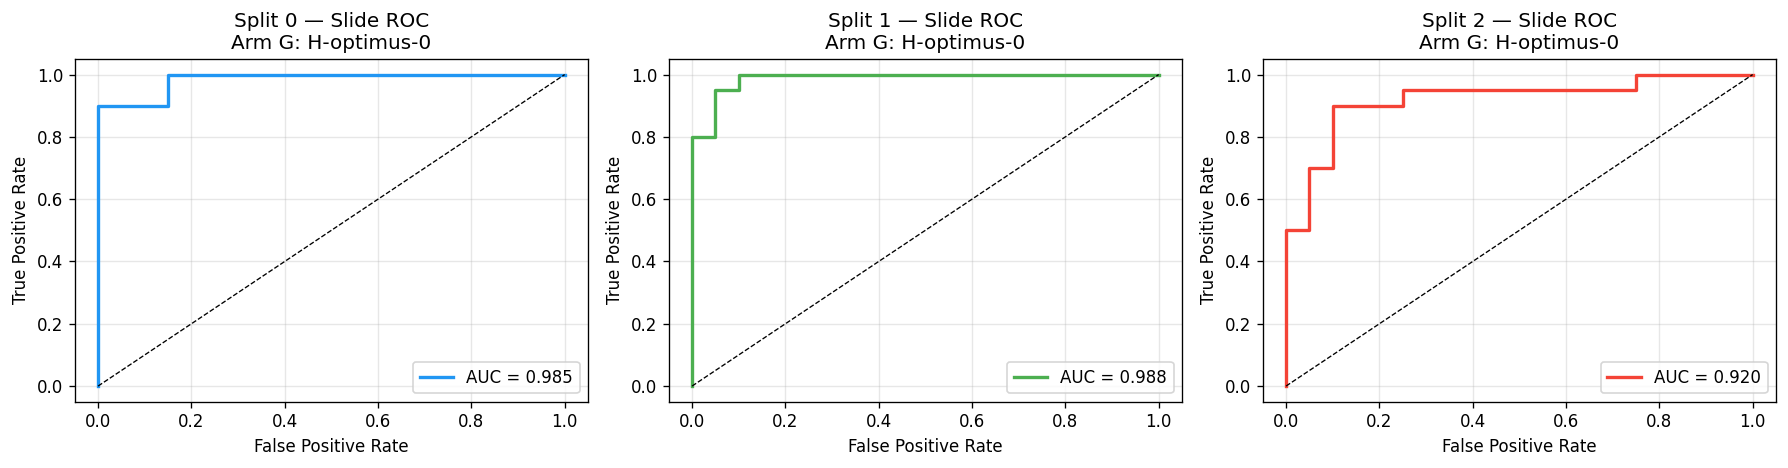

Attention map for sample test slide...


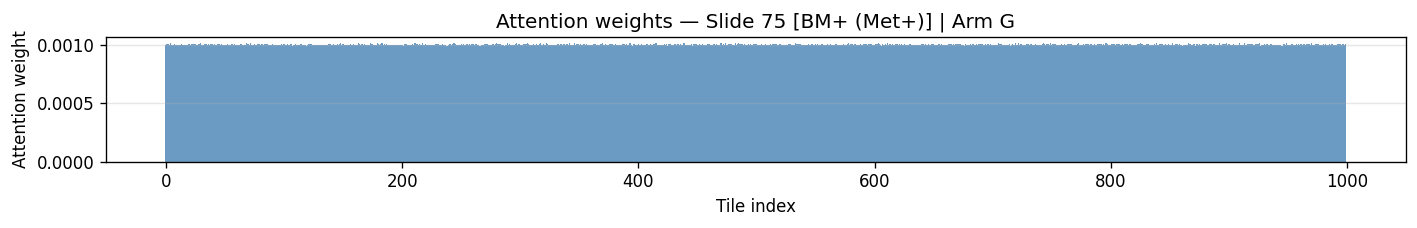

Top 10 attended tiles: [322 438 370  68 749 866 244 773 482 342]


In [12]:
# ── CELL 7 — Evaluation Plots ───────────────────────────────────────────────

fig, axes = plt.subplots(1, MIL_CFG['n_splits'], figsize=(5 * MIL_CFG['n_splits'], 4))
colors = ['#2196F3', '#4CAF50', '#F44336']

for i, (r, ax) in enumerate(zip(all_results, axes)):
    fpr, tpr, _ = roc_curve(r['y_true'], r['y_pred'])
    ax.plot(fpr, tpr, color=colors[i], lw=2, label=f'AUC = {r["slide_auc"]:.3f}')
    ax.plot([0,1],[0,1],'k--',lw=0.8)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'Split {i} — Slide ROC\nArm {ARM}: {CFG["name"]}')
    ax.legend(loc='lower right')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / f'arm_{ARM}_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Attention map for one test slide
print('Attention map for sample test slide...')
final_model = all_results[0]['model']
sample_sid  = all_results[0]['test_sids'][0]
sample_feats = torch.tensor(
    np.load(FEAT_DIR / f'slide_{sample_sid:04d}.npy'), dtype=torch.float32).to(device)
with torch.no_grad():
    _, attn = final_model(sample_feats, return_attention=True)
attn = attn.cpu().numpy()
fig, ax = plt.subplots(figsize=(12, 2))
ax.bar(range(len(attn)), attn, width=1.0, color='steelblue', alpha=0.8)
ax.set_xlabel('Tile index')
ax.set_ylabel('Attention weight')
lbl = 'BM+ (Met+)' if slide_to_label_bin[sample_sid] == 1 else 'C (Met-)'
ax.set_title(f'Attention weights — Slide {sample_sid} [{lbl}] | Arm {ARM}')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(RESULTS_DIR / f'arm_{ARM}_attention_slide{sample_sid}.png', dpi=150)
plt.show()
print(f'Top 10 attended tiles: {np.argsort(attn)[::-1][:10]}')



BENCHMARK RESULTS — NSCLC Brain-Met Prediction
Arm   Encoder                   AUC (mean+/-std)       Acc (mean+/-std)
----------------------------------------------------------------------
G     H-optimus-0               0.964+/-0.031          0.933+/-0.024

Zhou et al. baseline: Acc=0.87 (ResNet-18, end-to-end supervised)
Results saved: /kaggle/working/mil_benchmark/results/benchmark_summary.csv


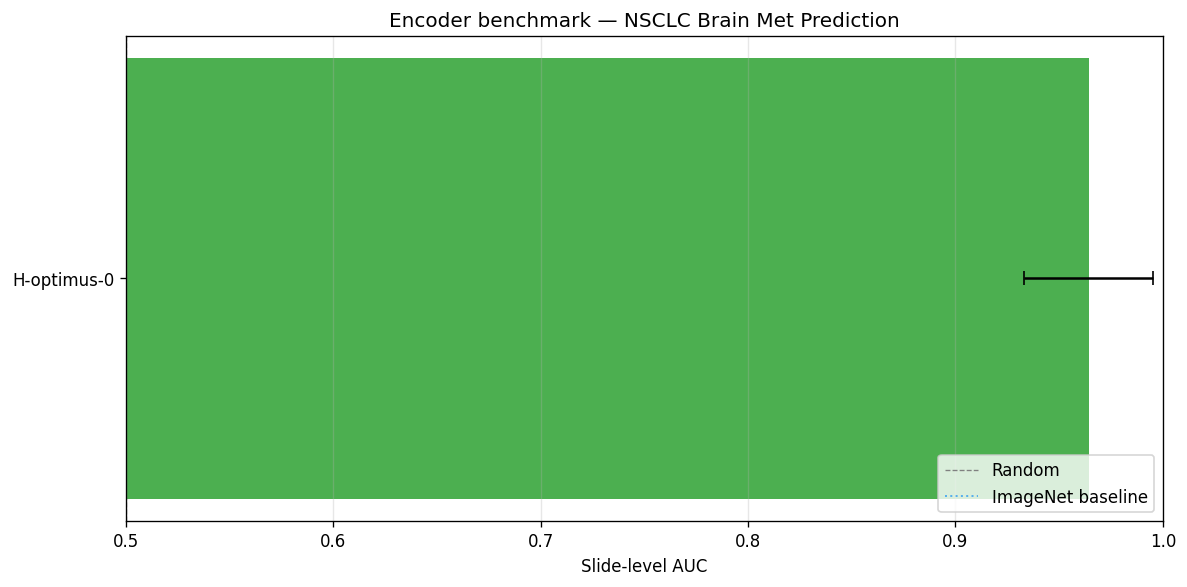

In [13]:
# ── CELL 8 — Benchmark Summary Table ────────────────────────────────────────
arm_names = {
    'A': 'ViT-Tiny DINO (TCIA)',
    'B': 'UNI',
    'C': 'CONCH',
    'D': 'ViT-Small ImageNet',
    'E': 'Virchow2',
    'F': 'Prov-GigaPath',
    'G': 'H-optimus-0',
    'H': 'Phikon-v2',
    'I': 'UNI2-h',
    'J': 'Hibou-L',
}

summary_rows = []
for arm in sorted(arm_names.keys()):
    aucs, accs = [], []
    for split_idx in range(MIL_CFG['n_splits']):
        yt_path = RESULTS_DIR / f'arm_{arm}_split{split_idx}_y_true.npy'
        yp_path = RESULTS_DIR / f'arm_{arm}_split{split_idx}_y_pred.npy'
        if not yt_path.exists():
            continue
        y_true = np.load(yt_path)
        y_pred = np.load(yp_path)
        aucs.append(roc_auc_score(y_true, y_pred))
        fpr, tpr, thresholds = roc_curve(y_true, y_pred)
        opt_thresh = thresholds[np.argmax(tpr - fpr)]
        accs.append(accuracy_score(y_true, (y_pred >= opt_thresh).astype(int)))
    if aucs:
        summary_rows.append({
            'Arm'            : arm,
            'Encoder'        : arm_names[arm],
            'Slide AUC Mean' : np.mean(aucs),
            'Slide AUC Std'  : np.std(aucs),
            'Slide Acc Mean' : np.mean(accs),
            'Slide Acc Std'  : np.std(accs),
            'N Splits'       : len(aucs),
        })

if summary_rows:
    df_summary = pd.DataFrame(summary_rows).sort_values('Slide AUC Mean', ascending=False)
    df_summary.to_csv(RESULTS_DIR / 'benchmark_summary.csv', index=False)
    print('\n' + '='*70)
    print('BENCHMARK RESULTS — NSCLC Brain-Met Prediction')
    print('='*70)
    print(f'{"Arm":<5} {"Encoder":<25} {"AUC (mean+/-std)":<22} {"Acc (mean+/-std)"}')
    print('-'*70)
    for _, row in df_summary.iterrows():
        print(f'{row["Arm"]:<5} {row["Encoder"]:<25} '
              f'{row["Slide AUC Mean"]:.3f}+/-{row["Slide AUC Std"]:.3f}          '
              f'{row["Slide Acc Mean"]:.3f}+/-{row["Slide Acc Std"]:.3f}')
    print('='*70)
    print('\nZhou et al. baseline: Acc=0.87 (ResNet-18, end-to-end supervised)')
    print(f'Results saved: {RESULTS_DIR / "benchmark_summary.csv"}')

    # ── Bar chart ─────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(10, 5))
    colors = ['#4CAF50' if row['Arm'] in ('B','C','E','F','G','H','I','J')
              else '#2196F3' if row['Arm'] == 'D'
              else '#FF9800'
              for _, row in df_summary.iterrows()]
    bars = ax.barh(df_summary['Encoder'], df_summary['Slide AUC Mean'],
                   xerr=df_summary['Slide AUC Std'], color=colors,
                   capsize=4, height=0.6)
    ax.axvline(0.5, color='gray', linestyle='--', linewidth=0.8, label='Random')
    ax.axvline(df_summary[df_summary['Arm']=='D']['Slide AUC Mean'].values[0]
               if 'D' in df_summary['Arm'].values else 0,
               color='#2196F3', linestyle=':', linewidth=1.2, alpha=0.7,
               label='ImageNet baseline')
    ax.set_xlabel('Slide-level AUC')
    ax.set_title('Encoder benchmark — NSCLC Brain Met Prediction')
    ax.legend(loc='lower right')
    ax.set_xlim(0.5, 1.0)
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'benchmark_bar.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No completed arms found. Run arms first, then re-run this cell.')


In [15]:
#treshold
for split_idx in range(MIL_CFG['n_splits']):
    yt_path = RESULTS_DIR / f'arm_G_split{split_idx}_y_true.npy'
    yp_path = RESULTS_DIR / f'arm_G_split{split_idx}_y_pred.npy'
    y_true = np.load(yt_path)
    y_pred = np.load(yp_path)
    fpr, tpr, thresholds = roc_curve(y_true, y_pred)
    opt = thresholds[np.argmax(tpr - fpr)]
    print(f'Split {split_idx}: optimal threshold = {opt:.3f}  '
          f'pred range = [{y_pred.min():.3f}, {y_pred.max():.3f}]')



Split 0: optimal threshold = 0.187  pred range = [0.004, 0.908]
Split 1: optimal threshold = 0.104  pred range = [0.017, 0.820]
Split 2: optimal threshold = 0.432  pred range = [0.010, 0.967]
